## Import libraries

In [26]:
import torch
import torch.nn as nn
import numpy as np
from pathlib import Path
from torchvision.utils import make_grid
from types import SimpleNamespace
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
from senn.models import *
from senn.models.senn import SENN
from senn.models.parameterizers import ConvParameterizer
from senn.models.conceptizers import ConvConceptizer, VaeConceptizer
from senn.models.aggregators import SumAggregator

In [4]:
plt.style.use('seaborn-v0_8-talk')

## Configuration

In [10]:
config = {
    "train": False,
    "conceptizer": "ConvConceptizer",
    "image_size": 28,
    "concept_dim": 1,
    "parameterizer": "ConvParameterizer",
    "cl_sizes": [1, 10, 20],
    "hidden_sizes": [320, 50],
    "num_concepts": 5,
    "num_classes": 10,
    "dropout": 0.5,
    "aggregator": "SumAggregator",
    "device": "cpu",
    "lr": 2e-4,
    "epochs": 20,
    "robustness_loss": "mnist_robustness_loss",
    "robust_reg": 1e-2,
    "concept_reg": 1,
    "print_freq": 100,
    "exp_name": "fashion_mnist_lambda1e-2_c5_seed29",
    "dataloader": "fashion_mnist",
    "data_path": "datasets/data/fashion_mnist_data",
    "batch_size" : 200,
    "sparsity_reg" : 2e-5,
    "eval_freq" : 270,
    "manual_seed": 29
  }
  
  
config = SimpleNamespace(**config)

## Load Trained Model

In [11]:
conceptizer = eval(config.conceptizer)(**config.__dict__)
parameterizer = eval(config.parameterizer)(**config.__dict__)
aggregator = eval(config.aggregator)(**config.__dict__)

In [12]:
model = SENN(conceptizer, parameterizer, aggregator)

In [13]:
checkpoint_path = Path('results')
model_file = checkpoint_path / config.exp_name / "checkpoints" / "best_model.pt" 
checkpoint = torch.load(model_file, map_location=config.device, weights_only=False)
print(f"Loading trained model: {model_file}")

Loading trained model: results/fashion_mnist_lambda1e-2_c5_seed29/checkpoints/best_model.pt


In [14]:
model.load_state_dict(checkpoint['model_state'])

<All keys matched successfully>

## Load data

In [28]:
from senn.datasets.dataloaders import get_dataloader
train_dl, val_dl, test_dl = get_dataloader(config)

x_b, y_b = next(iter(test_dl))

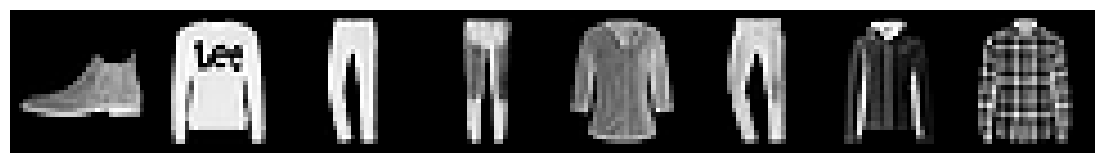

In [29]:
def denormalize(tensor, mean=0.2860, std=0.3530):
    return tensor * std + mean

grid = make_grid(denormalize(x_b[:8]), nrow=8, padding=2)
plt.figure(figsize=(14, 2))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
plt.axis('off')
plt.show()

## Add noise

In [30]:
import torch

def add_white_noise(images, sigma=0.05):
    # Create Gaussian noise with the same shape as your images
    noise = torch.randn_like(images) * sigma
    # Add noise and clip to keep pixel values between 0 and 1
    noisy_images = torch.clamp(images + noise, 0, 1)
    return noisy_images

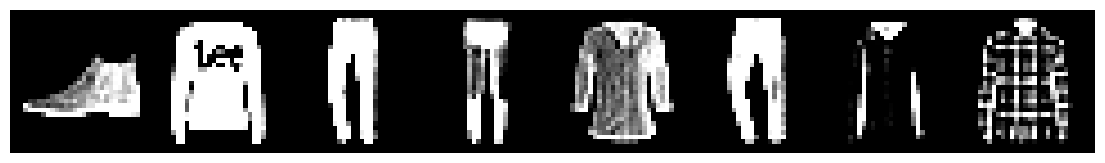

In [33]:
x_b_noise = add_white_noise(x_b[:8])
grid = make_grid(x_b_noise, nrow=8, padding=2)
plt.figure(figsize=(14, 2))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
plt.axis('off')
plt.show()